Feature Enginnering

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import warnings

In [2]:
# Importing the Csv data as Pandas data frame
data = pd.read_csv('Calories.csv')

In [3]:
data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190,94,29,105,40.8,231
1,14861698,female,20,166,60,14,94,40.3,66
2,11179863,male,69,179,79,5,88,38.7,26
3,16180408,female,34,179,71,13,100,40.5,71
4,17771927,female,27,154,58,10,81,39.8,35


In [4]:
to_remove = ['User_ID', 'Weight']
data.drop(to_remove, axis=1, inplace=True)

In [5]:
data.head()

,Gender,Age,Height,Duration,Heart_Rate,Body_Temp,Calories
0,male,68,190,29,105,40.8,231
1,female,20,166,14,94,40.3,66
2,male,69,179,5,88,38.7,26
3,female,34,179,13,100,40.5,71
4,female,27,154,10,81,39.8,35


In [6]:
# Preparing X and Y
X = data.drop(columns= 'Calories' , axis = 1)
y = data['Calories']

In [7]:
# Since all are numerical variable except One Categorical variable Gender .
# We do one Label encoding on Categorical variables and Standard scaling on Numerical variable.
num_features = [feat for feat in X.columns if X[feat].dtype != 'O' and X[feat].nunique() >= 15]

cat_features = [feat for feat in X.columns if X[feat].nunique() < 15]

In [37]:
print(num_features)
print(cat_features)

['Age', 'Height', 'Duration', 'Heart_Rate', 'Body_Temp']
['Gender']


In [9]:
# Colomn transformer with 3 types of transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop= 'first')

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [10]:
X = preprocessor.fit_transform(X)

In [11]:
X.shape

(15000, 6)

In [12]:
X[0]

array([1.        , 1.48472604, 1.08958204, 1.61912727, 0.98940395,
       0.99402302])

In [13]:
# Seperate dataset for Train and Test
from sklearn.model_selection import train_test_split
X_train,X_test , y_train , y_test = train_test_split(X,y,test_size= 0.2 , random_state= 42)
print(X_train.shape , y_train.shape)
print(X_test.shape , y_test.shape)

(12000, 6) (12000,)
(3000, 6) (3000,)


In [14]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [15]:

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression" : Ridge(),
    "Lasso Regression" : Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 11.3108
- Mean Absolute Error: 8.3299
- R2 Score: 0.9669
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 11.5548
- Mean Absolute Error: 8.4814
- R2 Score: 0.9669


Ridge Regression
Model performance for Training set
- Root Mean Squared Error: 11.3109
- Mean Absolute Error: 8.3297
- R2 Score: 0.9669
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 11.5550
- Mean Absolute Error: 8.4812
- R2 Score: 0.9669


Lasso Regression
Model performance for Training set
- Root Mean Squared Error: 12.2837
- Mean Absolute Error: 9.0226
- R2 Score: 0.9610
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 12.6030
- Mean Absolute Error: 9.1554
- R2 Score: 0.9606


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.0091
- Mean Absolute Error: 0.0002
- R2 Score: 1.0000
---

In [16]:
pd.DataFrame(list(zip(model_list,r2_list)),columns= ["Model Name", "R2_score"]).sort_values(by = ['R2_score'],ascending=False)

,Model Name,R2_score
5,XGBRegressor,0.998521
4,Random Forest Regressor,0.997908
3,Decision Tree,0.993272
0,Linear Regression,0.966918
1,Ridge Regression,0.966917
6,AdaBoost Regressor,0.964771
2,Lasso Regression,0.960643


In [17]:
#Initialize few parameter for Hyperparamter tuning

linear_params = {}

decision_tree_params = {
            "criterion": ['squared_error', 'absolute_error'],
            #"criterion":['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
            "max_depth": [ 5, 10, 15],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5],
            # 'splitter':['best','random'],
            "max_features": [ 'sqrt', 'log2']}


random_forest_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [ 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ['sqrt', 'log2']
}

In [18]:
# Models list for Hyperparameter tuning
gridcv_models = [
                ("Linear",LinearRegression(),linear_params),  
                ("Decision",DecisionTreeRegressor(),decision_tree_params),
                ("RandomForest", RandomForestRegressor(),random_forest_params)
               ]

In [19]:
##Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

model_param = {}
for name, model, params in gridcv_models:
    grid = GridSearchCV(estimator=model,
                                   param_grid=params,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    grid.fit(X_train, y_train)
    model_param[name] = grid.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Fitting 3 folds for each of 162 candidates, totalling 486 fits
---------------- Best Params for Linear -------------------
{}
---------------- Best Params for Decision -------------------
{'criterion': 'absolute_error', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5}
---------------- Best Params for RandomForest -------------------
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [20]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# -----------------------------
# Models with best parameters
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor(
        criterion='absolute_error',
        max_depth=15,
        max_features='log2',
        min_samples_leaf=1,
        min_samples_split=5
    ),
    "Random Forest Regression": RandomForestRegressor(
        max_depth=15,
        max_features='log2',
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=500,
        random_state=42
    )
}

# -----------------------------
# Training & Evaluation Loop
# -----------------------------
model_list = []
r2_list = []

OVERFIT_THRESHOLD = 0.05  # difference threshold

for name, model in models.items():
    print(f"🔹 {name}")
    
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluation
    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    # Store results
    model_list.append(name)
    r2_list.append(test_r2)

    # Print results
    print("Model performance for Training set")
    print(f"- RMSE: {train_rmse:.4f}")
    print(f"- MAE: {train_mae:.4f}")
    print(f"- R2 Score: {train_r2:.4f}")

    print('----------------------------------')

    print("Model performance for Test set")
    print(f"- RMSE: {test_rmse:.4f}")
    print(f"- MAE: {test_mae:.4f}")
    print(f"- R2 Score: {test_r2:.4f}")

    # -----------------------------
    # Overfitting Detection
    # -----------------------------
    diff = abs(train_r2 - test_r2)

    if train_r2 > 0.95 and test_r2 < 0.85:
        print("⚠️ Severe Overfitting")
    elif diff > OVERFIT_THRESHOLD:
        print("⚠️ Mild Overfitting")
    elif train_r2 < 0.7 and test_r2 < 0.7:
        print("⚠️ Underfitting")
    else:
        print("✅ Good Fit (Generalizing well)")

    # -----------------------------
    # Cross Validation (Important)
    # -----------------------------
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"📊 Cross-validation R2: {cv_scores.mean():.4f}")

    print("=" * 40)
    print("\n")

    



🔹 Linear Regression
Model performance for Training set
- RMSE: 11.3108
- MAE: 8.3299
- R2 Score: 0.9669
----------------------------------
Model performance for Test set
- RMSE: 11.5548
- MAE: 8.4814
- R2 Score: 0.9669
✅ Good Fit (Generalizing well)
📊 Cross-validation R2: 0.9668


🔹 Decision Tree Regression
Model performance for Training set
- RMSE: 4.3079
- MAE: 2.1833
- R2 Score: 0.9952
----------------------------------
Model performance for Test set
- RMSE: 9.3561
- MAE: 6.0633
- R2 Score: 0.9783
✅ Good Fit (Generalizing well)
📊 Cross-validation R2: 0.9747


🔹 Random Forest Regression
Model performance for Training set
- RMSE: 1.4351
- MAE: 0.9375
- R2 Score: 0.9995
----------------------------------
Model performance for Test set
- RMSE: 3.3181
- MAE: 2.1785
- R2 Score: 0.9973
✅ Good Fit (Generalizing well)
📊 Cross-validation R2: 0.9964




Feature Names Used in SHAP:
['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5']

Training: Random Forest Regression

Creating SHAP Explainer...

Calculating SHAP Values...

Generating SHAP Summary Plot...


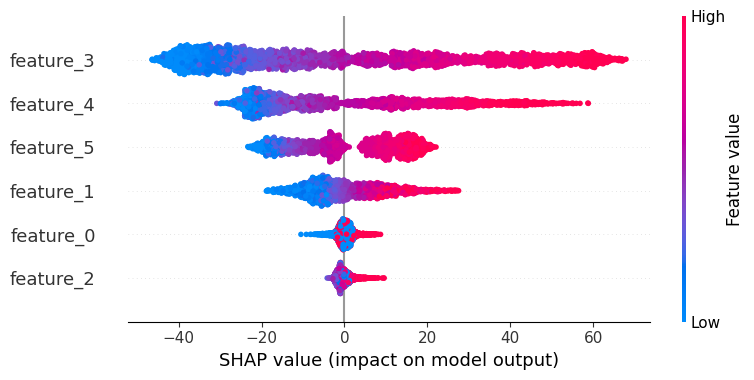


Generating SHAP Bar Plot...


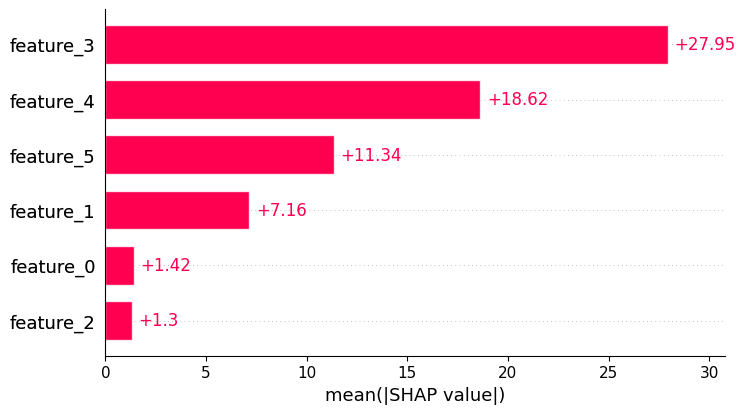


Generating Waterfall Plot for sample 0...


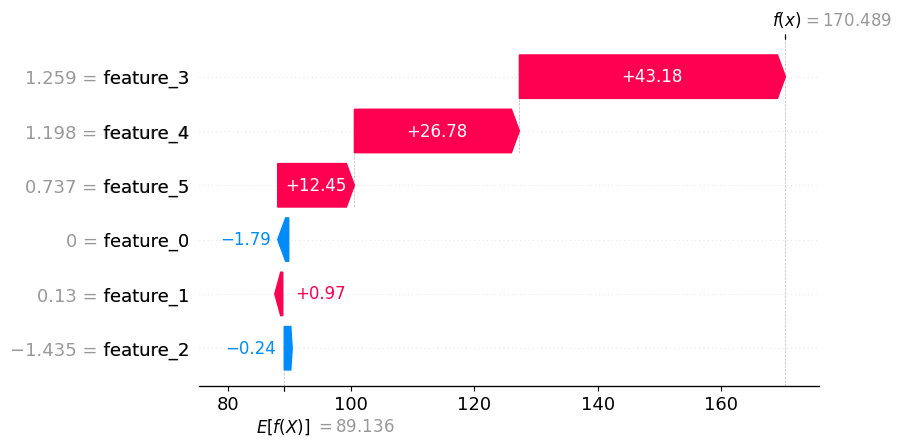


Generating Force Plot...



Generating Dependence Plot for: feature_0


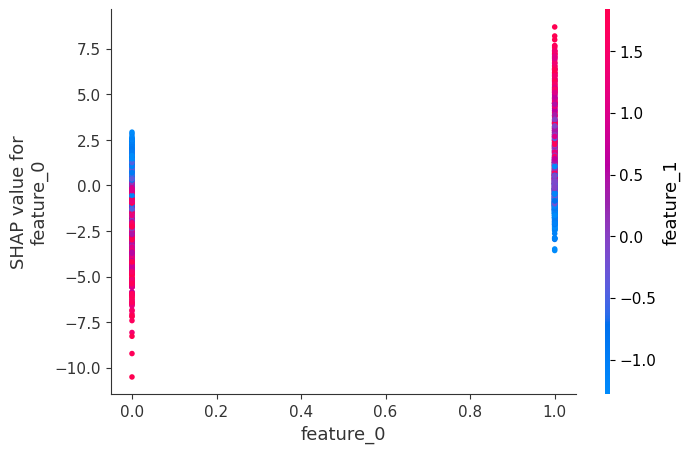


✅ SHAP Analysis Completed Successfully!


In [ ]:
# =========================================================
# COMPLETE SHAP CODE WITH FEATURE NAME FIX
# =========================================================

# Install if needed:
# pip install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# CHECK FEATURE NAMES
# =========================================================

# If X_train is already a DataFrame
if isinstance(X_train, pd.DataFrame):

    X_train_df = X_train.copy()
    X_test_df = X_test.copy()

    feature_names = X_train_df.columns.tolist()

# If X_train is NumPy array
else:

    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    X_test_df = pd.DataFrame(X_test, columns=feature_names)

print("===================================")
print("Feature Names Used in SHAP:")
print(feature_names)
print("===================================")

# =========================================================
# MODELS
# =========================================================

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree Regression": DecisionTreeRegressor(
        criterion='absolute_error',
        max_depth=15,
        max_features='log2',
        min_samples_leaf=1,
        min_samples_split=5
    ),

    "Random Forest Regression": RandomForestRegressor(
        max_depth=15,
        max_features='log2',
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=500,
        random_state=42
    )
}

# =========================================================
# SELECT MODEL
# =========================================================

model_name = "Random Forest Regression"

model = models[model_name]

print(f"\nTraining: {model_name}")

# =========================================================
# TRAIN MODEL
# =========================================================

model.fit(X_train_df, y_train)

# =========================================================
# CREATE SHAP EXPLAINER
# =========================================================

print("\nCreating SHAP Explainer...")

# Tree models
if isinstance(model, (DecisionTreeRegressor, RandomForestRegressor)):

    explainer = shap.TreeExplainer(model)

# Linear Regression
elif isinstance(model, LinearRegression):

    explainer = shap.LinearExplainer(model, X_train_df)

# Generic fallback
else:

    explainer = shap.Explainer(model, X_train_df)

# =========================================================
# CALCULATE SHAP VALUES
# =========================================================

print("\nCalculating SHAP Values...")

shap_values = explainer(X_test_df)

# =========================================================
# SHAP SUMMARY PLOT
# =========================================================

print("\nGenerating SHAP Summary Plot...")

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_df,
    show=True
)

# =========================================================
# SHAP BAR PLOT
# =========================================================

print("\nGenerating SHAP Bar Plot...")

plt.figure()
shap.plots.bar(shap_values)

# =========================================================
# WATERFALL PLOT
# =========================================================

sample_index = 0

print(f"\nGenerating Waterfall Plot for sample {sample_index}...")

shap.plots.waterfall(shap_values[sample_index])

# =========================================================
# FORCE PLOT
# =========================================================

print("\nGenerating Force Plot...")

shap.initjs()

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values.values[sample_index],
    X_test_df.iloc[sample_index],
    feature_names=feature_names
)

force_plot

# =========================================================
# DEPENDENCE PLOT
# =========================================================

feature_to_plot = feature_names[0]

print(f"\nGenerating Dependence Plot for: {feature_to_plot}")

shap.dependence_plot(
    feature_to_plot,
    shap_values.values,
    X_test_df
)

# =========================================================
# OPTIONAL: SAVE SHAP SUMMARY PLOT
# =========================================================

# plt.savefig("shap_summary.png", bbox_inches='tight')

print("\n✅ SHAP Analysis Completed Successfully!")

In [38]:
print(X_train_df)

       feature_0  feature_1  feature_2  feature_3  feature_4  feature_5
0            1.0  -0.340984   0.318066  -1.025445  -1.515029  -0.674346
1            1.0  -1.165498   1.440271   1.258504   1.511161   0.609015
2            1.0  -0.576559   0.458341  -0.424406  -0.784569   0.095670
3            0.0   1.366938  -1.295105  -0.785029  -1.932434  -0.674346
4            0.0  -0.635453  -2.136759  -1.265861  -0.575866  -1.316027
...          ...        ...        ...        ...        ...        ...
11995        0.0   1.896983  -1.856207   0.777672   0.885053   0.737351
11996        0.0  -1.283285  -0.172899   0.537257   0.885053   0.865687
11997        1.0   0.836894   1.019444  -0.905237  -0.575866  -0.674346
11998        1.0  -0.458771  -0.032623  -0.424406   0.154593   0.224006
11999        1.0  -0.988816   0.528479   0.056426  -0.471515   0.609015

[12000 rows x 6 columns]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from lime.lime_tabular import LimeTabularExplainer

# -----------------------------
# STEP 1: Create feature names manually
# (YOU MUST KNOW NUMBER OF FEATURES)
# -----------------------------
feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# -----------------------------
# STEP 2: Convert to DataFrames (optional but cleaner)
# -----------------------------
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# -----------------------------
# STEP 3: Train model
# -----------------------------
lr_model = LinearRegression()
lr_model.fit(X_train_df, y_train)

# -----------------------------
# STEP 4: Create LIME explainer
# -----------------------------
explainer = LimeTabularExplainer(
    training_data=X_train_df.values,
    feature_names=feature_names,
    mode='regression'
)

# -----------------------------
# STEP 5: Explain one prediction
# -----------------------------
sample_index = 0

exp = explainer.explain_instance(
    data_row=X_test_df.iloc[sample_index].values,
    predict_fn=lr_model.predict,
    num_features=5
)

# -----------------------------
# STEP 6: Print explanation
# -----------------------------
print("\n🔍 LIME Explanation:\n")

for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")

# -----------------------------
# STEP 7: Save BEAUTIFIED result
# -----------------------------

html_data = exp.as_html()

better_style = """
<style>
    body {
        font-family: Arial, sans-serif;
        background: #0f172a;
        color: #e2e8f0;
        padding: 30px;
    }

    table {
        border-collapse: collapse;
        width: 80%;
        margin: auto;
        background: #1e293b;
        border-radius: 12px;
        overflow: hidden;
        box-shadow: 0 10px 25px rgba(0,0,0,0.4);
    }

    th, td {
        padding: 12px;
        text-align: left;
    }

    th {
        background: #334155;
        color: #f8fafc;
    }

    tr:nth-child(even) {
        background: #273449;
    }

    tr:hover {
        background: #3b82f6;
        color: white;
        transition: 0.2s;
    }

    h1, h2, h3 {
        text-align: center;
        color: #38bdf8;
    }
</style>
"""

final_html = f"""
<html>
<head>
{better_style}
</head>
<body>
{html_data}
</body>
</html>
"""

with open("lime_linear_regression_beauty.html", "w", encoding="utf-8") as f:
    f.write(final_html)

print("✅ Saved: lime_linear_regression_beauty.html")


🔍 LIME Explanation:

feature_3 > 0.90: 96.0661
feature_4 > 0.78: 34.8232
0.22 < feature_5 <= 0.74: -9.6616
-0.22 < feature_1 <= 0.78: 3.9126
feature_2 <= -0.73: -2.7034
✅ Saved: lime_linear_regression_beauty.html


c:\Users\emad\Desktop\calorie\Calories_burned_prediction_ml\venv\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
pd.DataFrame(list(zip(model_list,r2_list)),columns= ["Model Name", "R2_score"]).sort_values(by = ['R2_score'],ascending=False)

,Model Name,R2_score
2,Random Forest Regression,0.997272
1,Decision Tree Regression,0.977707
0,Linear Regression,0.966918
